# Protocolos de monitoreo escalables en sistemas Cloud

In [1]:
#using Pkg;Pkg.instantiate(); Pkg.update()

In [2]:
using Plots, LaTeXStrings, Distributions, Printf
default(size=(800,500))

## Problema.

Tenemos un clúster con $N$ nodos de cómputo (servidores, contenedores, VMs). Queremos detectar *rápidamente* cuándo uno falla. La pregunta no es si podemos monitorear, sino **cómo escala** el costo cuando $N$ pasa de decenas a $10^4$–$10^6$ nodos como en un sistema Cloud (e.g. Kubernetes).

**Algunas alternativas:**

 * Monitoreo **centralizado**: colocar un nodo monitor (o varios) a mantener el estado de cada nodo. 
 * **Gossip**: algoritmo de control distribuido, donde cada nodo se hace cargo de monitorear a algunos vecinos. Veremos cómo escala.

**Problemas a analizar:**
  * ¿Push o pull? Es decir, ¿cada nodo avisa o cada nodo pregunta? Diferencias de implementación.Push **funciona bien al arrancar pero desperdicia contactos al saturar**.
  * Combinación de estrategias y costo de mensajes asociados.
  * Ejemplos prácticos (SWIM).

## Monitoreo centralizado

Antes de comenzar, definamos dos términos que reaparecen en todo lo que sigue:

- **Push:** el nodo que *tiene* la información la empuja hacia otro.
- **Pull:** el nodo que *no la tiene* la pide a otro y la obtiene de él (si la tiene).

En el caso de monitoreo centralizado, un **monitor central** mantiene la lista de los $N$ nodos:

- **Push centralizado:** el monitor *pinguea* a cada nodo y espera respuesta. 
- **Pull centralizado:** los nodos mandan *heartbeats*; el monitor debe *procesar* $N$ por período.

Lo esencial no cambia, simplemente quién se hace cargo de enviar los mensajes.

### Retardo y costo del monitoreo centralizado

Supongamos un modelo **push**, el monitor pinguea los $N$ nodos en orden:

  - Supongamos que puede mandar $b$ msg/s.
  - Para recorrer los $N$ nodos requiere un período $T = N/b$.
  - Si uno no contesta, lo da por fallido.

Entonces el tiempo de detección es de peor caso es:

$$ T_{\text{det}} = T = \frac{N}{b} = O(N). $$

Supongamos que el nodo que falla en realidad es aleatorio, con probabilidad $1/N$. En ese caso:

 * Estoy en un momento del ciclo de monitoreo, por ejemplo en el nodo $k$.
 * Falla uno, puede ser el siguiente $k+1$ o el anterior o cualquiera. Modelemos esto como una $\textrm{Uniforme}\{1,\ldots,N\}$.
 * El tiempo medio hasta detectarlo es el tiempo medio hasta encontrarlo, eso requiere recorrer medio ciclo de monitoreo en promedio.

Por lo tanto, en esta situación:

$$T_{\text{det}} = E[T] = \frac{N}{2b} = O(N).$$

Es decir la ganancia no es significativa.

### Ejemplo numérico

Supongamos que el monitor es capaz de sostener $b=1000$ msg/s, entonces para el peor caso:

| $N$ | $T_{\text{det}}=N/b$ |
|---|---|
| $10^3$ | 1 s |
| $10^4$ | 10 s |
| $10^5$ | 100 s ($\approx$1.7 min) |
| $10^6$ | 1000 s ($\approx$17 min) |

  * Con $N=10^6$, una falla tarda **~17 minutos** en notarse.
  * Alternativamente, si exigimos por ejemplo $T_{\text{det}}\leqslant 2$s requeriría $b\geqslant N/2=5\times10^5$ msg/s. El orden de mensajes es $O(N)$ llegando al monitor: insostenible.

### Evolución con la escala

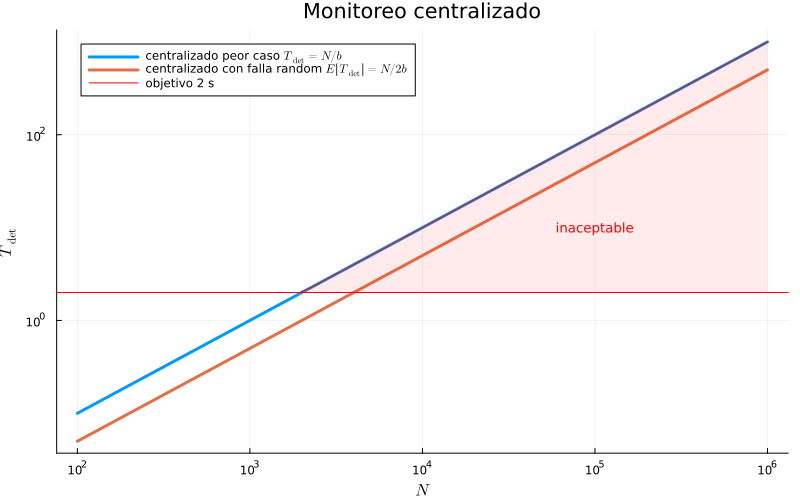

In [3]:
b = 1000.0                         # msg/s sostenibles por el monitor
Ns = 10.0 .^ range(2, 6, length=60)
Tdet = Ns ./ b
Tdet_random = Ns./(2b)

plot(Ns, Tdet, xscale=:log10, yscale=:log10,
            xlabel=L"N", ylabel=L"T_{\textrm{det}}",
            label="centralizado peor caso "*L"T_{\textrm{det}} = N/b", lw=3, legend=:topleft,
            title="Monitoreo centralizado")
plot!(Ns, Tdet_random, xscale=:log10, yscale=:log10,
            label="centralizado con falla random "*L"E[T_\textrm{det}]= N/2b", lw=3, legend=:topleft,
            title="Monitoreo centralizado")
hline!([2.0], c=:red, label="objetivo 2 s")

# zona inaceptable (por encima del objetivo)
plot!(Ns, max.(Tdet, 2.0), fillrange=2.0, fillalpha=0.08, c=:red, label="")
annotate!(1e5, 10, text("inaceptable", :red, 9))

### Modelo push

En este modelo, cada nodo envía un *heartbeat* al monitor. Si el mensaje de heartbeat no llega, se lo da por caído.

 * A primera vista esto es más eficiente: al detectar la falta de heartbeat el monitor inmediatamente da cuenta de la falla.
 * El problema es que el monitor se vuelve un *cuello de botella* de todos modos.

Supongamos que fijamos el heartbeat a $t_0$ por ejemplo $2s$, para que la falla se detecte rápidamente:
 * El monitor recibe $N/t_0$ mensajes por segundo!
 * Si $N\sim 10^5$ son $50000$ mensajes por segundo.

Es decir, el orden de los mensajes por segundo sigue siendo $O(N)$. Si la capacidad del servidor de procesar mensajes es $b$ mensajes por segundo, necesitamos:

$$\frac{N}{t_0} < b \Rightarrow t_0>\frac{N}{b},$$

es decir, el tiempo de detección de falla ($t_0$) es del orden de $N$ nuevamente.

### Primera solución: agregar más monitores.

La primera idea ante el $O(N)$ es **repartir** el trabajo entre $k$ monitores, cada uno a cargo de $N/k$ nodos. Analicemos esto.

**Ventajas:**

 * La carga por monitor baja a $O(N/k)$ y mejoramos los tiempos de detección.
 * Cambiamos un único punto de falla por $k$. Si un monitor falla solo tenemos $N/k$ sin monitorear temporalmente.

**Desventajas:**

 * Cada monitor puede fallar a su vez. ¿Quién monitorea a los monitores?
 * Si un monitor falla, ¿cuánto cuesta reconstruir la asignación?

### Modelo sencillo

Supongamos que cada monitor falla como una cadena de Markov ON-OFF.

![cadena ON OFF](../images/cadena_on_off.png)

* Tasa de falla: $\mu$. Tasa de recuperación $\lambda$ (en general $\lambda\gg \mu$.
* En estado estacionario

  $$\pi_{0} = \frac{\mu}{\lambda+\mu}, \quad 0 < \pi_0 \ll 1.$$
  
* Con $k$ monitores hay, en promedio, $k\pi_0$ caídos *en todo momento*, y sus $N/k$ nodos quedan sin vigilancia hasta reasignar.

Es decir tenemos una fracción permanente $\pi_0 N$ sin monitorear, independiente de $k$!!

* Es decir el tiempo de detección mejora.
* Pero las propias fallas de los monitores contrarrestan esto.

### El problema de coordinación

Se agrega además que, al caer un monitor hay que:

 * Detectar la caída. ¿Quién vigila a los vigilantes?
 * Acordar cómo repartir los $N/k$ nodos entre los que permanecen activos.
 * Propagar esa asginación entre todos los monitores.

**Modelo:**

* La falla de algún monitor ocurre a tasa $k\mu$.
* Cada re-coordinación cuesta $C(k)$ mensajes (en general al menos lineal)

El tráfico de mensajes de control en estado estacionario es:

$$ R_{\textrm{control}} \approx k\mu\,C(k). $$

Subir $k$ **aumenta** el costo de re-coordinación: hay un balance, no se puede subir $k$ indefinidamente.



### Ejemplo

Supongamos que cada monitor es capaz de:
* Enviar $b$ mensajes por segundo para monitorear a sus $N/k$ nodos.
* Por cada falla (de otro), debe enviar $c$ mensajes para recoordinar con los demás.

Tasa de mensajes de un monitor:

$$ r(k) = \frac{bN}{k} + \underbrace{\pi_1}_{\approx 1}\, \mu k  c $$

Derivando para hallar el $k$ óptimo:

$$ r'(k) = -\frac{bN}{k^2} + \mu c = 0 \Rightarrow k^* \approx \sqrt{\frac{bN}{\mu c}}.$$

Es decir, precisamos $O(\sqrt{N})$ monitores, que igual a su vez es grande para monitorear.

**Pregunta:** Y si renunciamos a la coordinación centralizada, ¿qué podemos hacer?

## Protocolos Gossip

**Idea:** 
 * Cada nodo se encarga de monitorear un número *pequeño* de los otros.
 * Al detectar una falla, propaga la información a otros nodos al azar.

**Protocolo:**

 * Cada nodo contacta otro nodo al azar cada un tiempo exponencial de tasa $\beta$ (frecuencia de contacto o monitoreo).
 * Si no contesta: se declara caído y en los otros contactos con otros nodos hago "piggybacking".
 * Es decir, en el mismo mensaje de "ping" agrego que "el nodo $j$ está caído" para propagar la información.

Notemos que la tasa total de mensajes es $N\beta$, o bien $\beta$ por nodo, $O(N)$ igual que antes, pero descentralizada entre los nodos individuales.

### Modelo de Markov

Supongamos que tenemos $N+1$ nodos y un nodo falla. ¿Cuánto tiempo demoramos en propagar la información a todos?

**Modelo:**

Sea $I(t)$ el número de nodos **informados** ("infectados") y $S(t)=N-I(t)$ los "susceptibles", es decir los que aún no se enteraron. La información se propaga como un virus!
 
 * Inicialmente $I(0)=1$ (o pequeño, si varios lo detectaron).
 * Los $I$ infectados en tiempo $t$ generan un nuevo contacto a tasa $\beta$ cada uno. Tasa total: $\beta I$.
 * Como los contactos son al azar, cada uno cae en un susceptible con probabilidad $S/N$. Entonces:
 
 $$I\to I+1 \quad \textrm{a tasa} \quad \beta\,I\,\frac{N-I}{N}. $$

Cadena de Markov de **nacimiento puro** sobre $I\in\{1,\dots,N\}$. Eventualmente llega a $I=N$. ¿Cuánto demora?

### Modelo fluido: la ecuación logística

Pasemos a un modelo fluido: sea $i(t) = I(t)/N$ la *fracción* de nodos infectados, y $s(t)$ la de susceptibles. Al cabo de un tiempo $dt$ se tiene que en promedio:

$$i(t+dt) \approx \frac{I(t)}{N} + \beta \frac{I(t)}{N} \frac{N-I(t)}{N} = i(t) + \beta i(t) (1-i(t)).$$

de donde tenemos la ecuación diferencial:

$$ \frac{di}{dt} = \beta\,i\,(1-i), \qquad i(0)=\tfrac1N, $$

Esta ecuación se denomina **ecuación logística** y su solución es:

$$ i(t) = \frac{i_0\,e^{\beta t}}{1-i_0+i_0\,e^{\beta t}},$$

con $i_0 = 1/N >0$ (observar que $i=0$ es equilibrio).

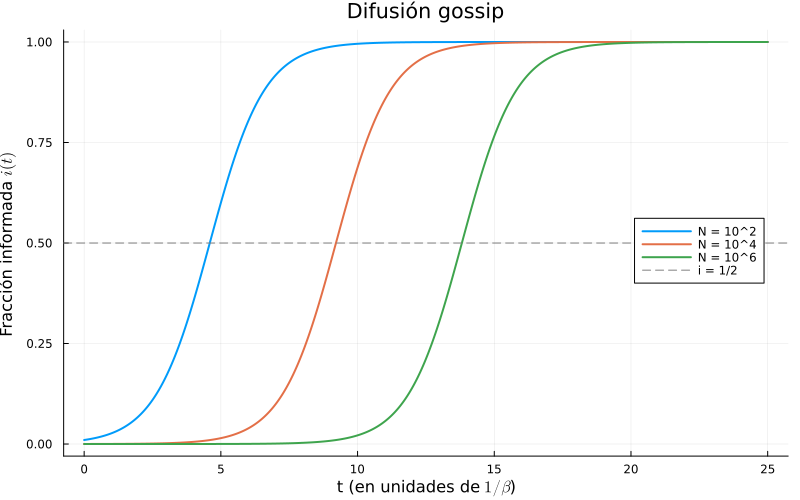

In [4]:
# CELDA 2 — Curva logística (fluido) para distintos N
β = 1.0
logistic(t, β, i0) = (i0*exp(β*t))/(1-i0+i0*exp(β*t))

ts = 0:0.05:25
plot(xlabel="t (en unidades de "*L"1/\beta"*")", ylabel="Fracción informada "*L"i(t)",
            title="Difusión gossip", legend=:right)
for N in (1e2, 1e4, 1e6)
    plot!(ts, logistic.(ts,β, 1/N), lw=2,
          label="N = 10^$(Int(round(log10(N))))")
end
hline!([0.5], ls=:dash, c=:gray, label="i = 1/2")

### Simulación por eventos

La logística es el *promedio*. El proceso real es estocástico. Simulemos entonces la epidemia como la cadena de Markov anterior:

In [5]:
# CELDA 2b — Simulación por eventos de la epidemia (pull) vs fluido, N=100 y N=10^4
function epidemia_eventos(N; β=1.0)
    I = 1; t = 0.0
    ts = Float64[0.0]; frac = Float64[I/N]
    while I < N
        λ = β * I * (N - I) / N          # tasa total de nueva información
        t += rand(Exponential(1/λ))            # tiempo al próximo evento ~ Exp(λ)
        I += 1
        push!(ts, t); push!(frac, I/N)
    end
    ts, frac
end

epidemia_eventos (generic function with 1 method)

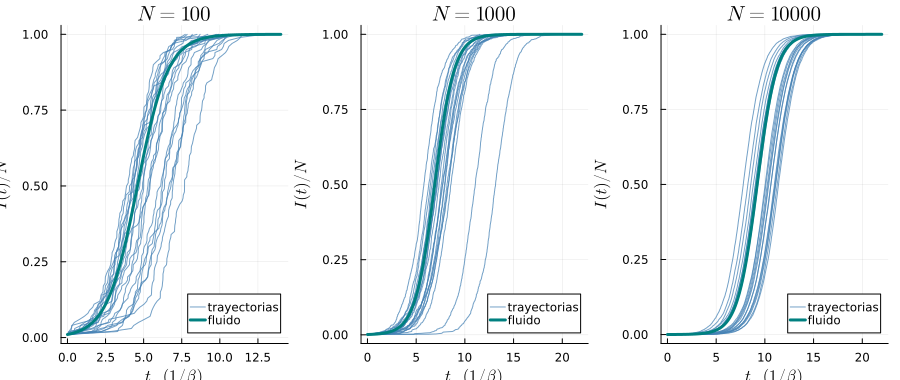

In [6]:
plots_conc = []
for N in (100, 1000, 10_000)
    p = plot(xlabel=L"t \quad (1/β)", ylabel=L"I(t)/N", title=L"N = %$N",
             legend=:bottomright)
    for r in 1:20
        ts_s, fr = epidemia_eventos(N)
        plot!(p, ts_s, fr, lw=1, alpha=0.75, c=:steelblue,
              label = r==1 ? "trayectorias" : "")
    end
    tt = 0:0.05:(N==100 ? 14 : 22)
    plot!(p, tt, logistic.(tt,β,1/N), lw=3, c=:teal, label="fluido")
    push!(plots_conc, p)
end
plot(plots_conc..., layout=(1,length(plots_conc)), size=(900,380))

### Tiempo de cobertura:

Observemos que el modelo fluido capta la esencia del estocástico. Presenta tres fases:

* **arranque exponencial** ($i\approx\frac1N e^{\beta t}$),
* **inflexión** tiempo $t_1$, llega a $i=1/2$, 
* **saturación** $i\to1$.

La fase de arranque puede aproximarse por $i(t)\approx i_0 e^{\beta t}\Rightarrow t_1\approx\frac1\beta\log\left(\frac{1}{2i_0}\right)$.

Recordando que $i_0=1/N$, se tiene que:

$$t_1 \approx \frac1\beta\log\left(\frac{N}{2}\right)$$.

Por simetría, la segunda parte de la propagación dura un tiempo similar, por lo que el tiempo total de propagación es:

$$ T_{\textrm{prop}} \approx \frac{2}{\beta}\log\left(\frac{N}{2}\right) = O(\log N). $$

**Observación:** El modelo fluido igual predice un tiempo infinito para llegar a $i=1$. Sin embargo, lo lógico es ver cuánto demora en llegar de $1/N$ a $1-1/N$ y ahí la cuenta vale. El último nodo igual se infecta rápidamente ya que alguno lo va a contactar en tiempo $O(1)$.

In [7]:
# Tiempo de cobertura de 1/N a 1-1/N sobre el fluido vs predicción (2/β) ln N/2
function t_cover(N; β=1.0)
    i0 = 1/N
    (1/β) * log((1-i0)^2/i0^2) 
end
@printf("%-10s %-20s %-20s\n", "N", "t_cover(99%) [1/β]", "(2/β) log (N/2)")
for N in (1e2,1e3,1e4,1e5,1e6)
    @printf("%-10.0f %-20.2f %-20.2f\n", N, t_cover(N), 2*log(N/2))
end

N          t_cover(99%) [1/β]   (2/β) log (N/2)     
100        9.19                 7.82                
1000       13.81                12.43               
10000      18.42                17.03               
100000     23.03                21.64               
1000000    27.63                26.24               


### Simulación

N = 10000, realizaciones = 500
  tiempo de absorción simulado : 19.518  (± 1.740  desv. est.)
  fluido  (2/β) ln(N-1)        : 18.420
  diferencia sim - fluido      : 1.097


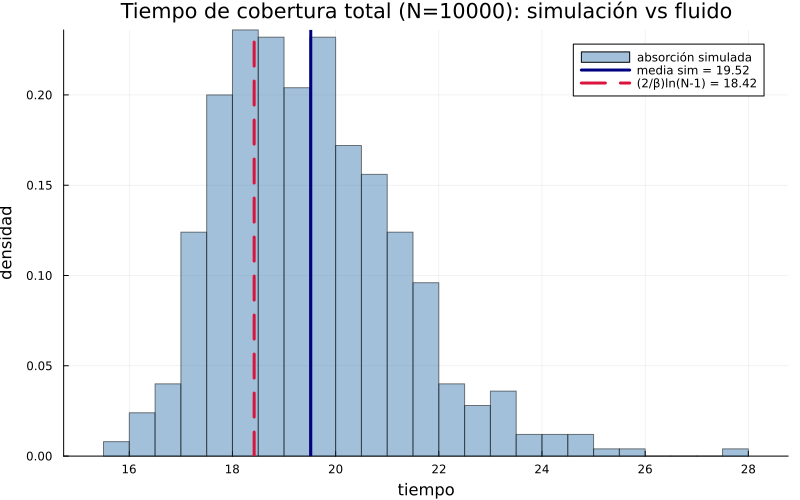

In [8]:
N   = 10000
β   = 1.0
R   = 500                                  # número de repeticiones

t_abs = Vector{Float64}(undef, R)
for r in 1:R
    ts, _ = epidemia_eventos(N; β=β)        # corre la cadena hasta I=N
    t_abs[r] = ts[end]                       # tiempo de absorción de esta realización
end

t_medio  = mean(t_abs)
t_std    = std(t_abs)
t_fluido = 2/β * log(N-1)                     # predicción fluida: 1/N → 1-1/N

@printf("N = %d, realizaciones = %d\n", N, R)
@printf("  tiempo de absorción simulado : %.3f  (± %.3f  desv. est.)\n", t_medio, t_std)
@printf("  fluido  (2/β) ln(N-1)        : %.3f\n", t_fluido)
@printf("  diferencia sim - fluido      : %.3f\n", t_medio - t_fluido)

# Histograma de los tiempos de absorción con las marcas de referencia
histogram(t_abs, bins=50, normalize=:pdf, alpha=0.5, c=:steelblue,
          label="absorción simulada", xlabel="tiempo", ylabel="densidad",
          title="Tiempo de cobertura total (N=$N): simulación vs fluido")
vline!([t_medio],  lw=3, c=:navy,    label=@sprintf("media sim = %.2f", t_medio))
vline!([t_fluido], lw=3, c=:crimson, ls=:dash, label=@sprintf("(2/β)ln(N-1) = %.2f", t_fluido))

### Comparación con el caso centralizado

Comparemos ahora de manera rigurosa ambos modelos. ¿Cuánto demoramos en detectar una falla y propagarla a todos los nodos?

* **Detección centralizada**:

  $$T_{\textrm{central}} = \underbrace{\frac{N}{2b}}_{\textrm{detección}} + \underbrace{\frac{N}{b}}_{\textrm{propagación}} = \frac{3N}{2} = O(N).$$

* **Detección por gossip**:

  $$T_{\textrm{gossip}} = \underbrace{1/\beta}_{\textrm{detección}} + \underbrace{\frac{2}{\beta}\log\left(\frac{N}{2}\right)}_{\textrm{propagación}} = O(\log(N))$$
  

Lo importante es que el *tiempo de detección de gossip$ es de orden 1. ¿Por qué?

 * Cada nodo sondea uno al azar a frecuencia $\beta$.
 * Hay $N$ nodos sondeando, por lo cual en promedio hay $1$ nodo sondeando a cualquier otro a tasa $\beta$.


## Push vs. Pull

El protocolo anterior es *push*, cada nodo informa a sus vecinos que descubrió una falla y ésta se propaga.

**Problema:** cuando una fracción $i$ alta de nodos ya conoce la falla, la mayoría de los push se vuelven inútiles. El nodo contactado muy probablemente ya esté avisado.

Cuantifiquemos esto: si hay $I$ nodos infectados y cada uno contacta al azar, la probabilidad de cada uno de contactar a uno susceptible es:

$$P(I\to S \mid I) = \frac{S}{N} = \frac{N-I}{N} \to 0.$$

Conclusión, en push, un infectado empuja **sin saber** si el otro ya sabe; acierta con probabilidad $\approx S/N=s\to0$. Al final, los $\approx N$ infectados siguen empujando a tasa $\beta N$ pero **casi todos los mensajes se desperdician**. Push es eficiente al arrancar, pero luego es excesivo.

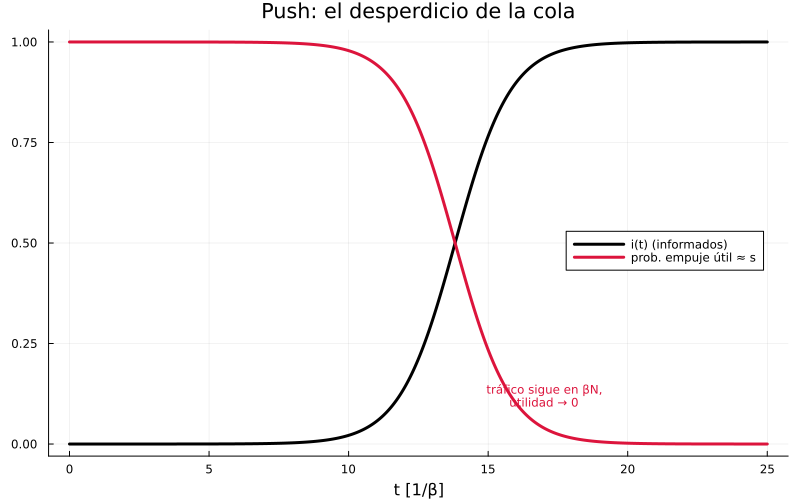

In [9]:
# CELDA 4 — Push: fracción de contactos útiles colapsa mientras el tráfico sigue
ts = 0:0.02:25
N = 1e6
ivals = logistic.(ts, β, 1/N)
util  = 1 .- ivals          # prob. de que un empuje acierte ≈ s = 1-i

plt4 = plot(xlabel="t [1/β]", title="Push: el desperdicio de la cola", legend=:right)
plot!(plt4, ts, ivals, lw=3, c=:black, label="i(t) (informados)")
plot!(plt4, ts, util,  lw=3, c=:crimson, label="prob. empuje útil ≈ s")
annotate!(plt4, 17, 0.12, text("tráfico sigue en βN,\nutilidad → 0", :crimson, 8))
plt4

## Protocolo pull: el comportamiento inverso

En **pull** los susceptibles preguntan: los $S$ generan contactos a tasa $\beta S$, cada uno acierta con probabilidad $I/N$. La tasa de nuevas infecciones es

$$I\mapsto I+1 \qquad \textrm{con tasa} \qquad \beta\,S\,\frac{I}{N}=\beta\,(N-I)\,\frac IN, $$

Es decir, preguntar al azar o informar al azar siguen **el mismo modelo** solo que la utilidad de sus mensajes es simétrica:

  * En la fase de crecimiento exponencial, conviene hacer *push*.
  * En la fase de saturación conviene hacer *pull*.


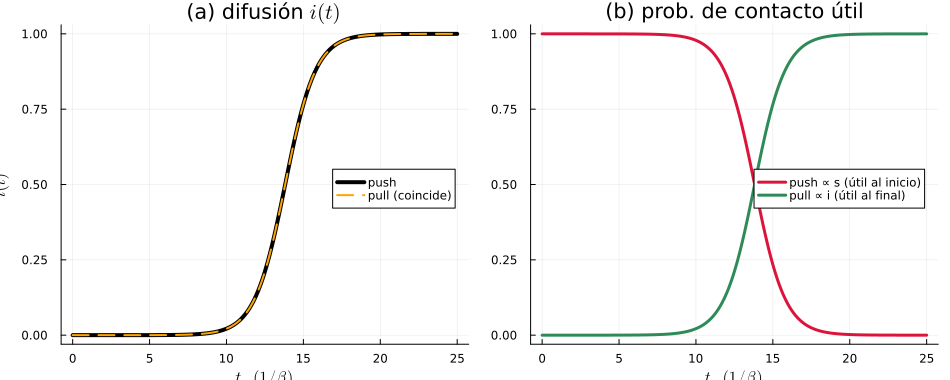

In [10]:
# CELDA 5 — (a) push y pull difunden IGUAL; (b) utilidad especular
ts = 0:0.02:25
N = 1e6
ivals = logistic.(ts,β,1/N)

pa = plot(ts, ivals, lw=4, c=:black, label="push", title="(a) difusión "*L"i(t)",
          xlabel=L"t\quad (1/β)", ylabel=L"i(t)", legend=:right)
plot!(pa, ts, ivals, lw=2, ls=:dash, c=:orange, label="pull (coincide)")
# Nota: coinciden a propósito — el modelo asíncrono las iguala (no es bug).

util_push = 1 .- ivals       # acierta si pega en susceptible: ∝ s
util_pull = ivals            # acierta si pregunta y el otro sabe: ∝ i
pb = plot(xlabel=L"t\quad (1/β)", title="(b) prob. de contacto útil", legend=:right)
plot!(pb, ts, util_push, lw=3, c=:crimson, label="push ∝ s (útil al inicio)")
plot!(pb, ts, util_pull, lw=3, c=:seagreen, label="pull ∝ i (útil al final)")
plot(pa, pb, layout=(1,2), size=(950,380))

## Push-pull y el conteo de mensajes

Si push gana al inicio y pull al final, lo natural es **push-pull**: cada contacto intercambia en ambos sentidos. Hereda el arranque de push y el apagado de pull, sin que ningún nodo sepa en qué fase global está.

La ventaja **no es de velocidad** (los tres difunden en $O(\log N)$), sino de **mensajes totales**:

$$ M_{\text{push}}=\beta\!\int_0^{t^*}\!\!N\,i\,dt,\qquad M_{\text{pull}}=\beta\!\int_0^{t^*}\!\!N\,(1-i)\,dt. $$

En push $i\to1$ se mantiene durante toda la cola (gasta aunque ya casi todos sepan). En pull $1-i\to0$ (el gasto se corta solo). 

**Resultado ideal:**

Si elegimos $t^*$ el tiempo en que se llega a la mitad de nodos infectados, el total de mensajes es aproximadamente $2N\log(2) \approx 1.39 N$. Es decir un overhead constante de 40%!

De todos modos esto no es fácil de implementar de manera descentralizada porque los nodos *no saben cuántos ya hay infectados*

## Un caso práctico: El protocolo SWIM.

SWIM (*Scalable Weakly-consistent Infection-style Process Group Membership*) se construye sumando piezas, donde **cada pieza corrige un defecto concreto de la anterior**. Lo vemos en ese orden, porque así se entiende por qué cada mecanismo existe.

### Punto de partida: el problema

Queremos que cada nodo sepa quién está vivo, con tres objetivos en tensión (no se pueden maximizar los tres a la vez):

- **Velocidad de detección:** tiempo entre que un nodo falla y *alguien* lo nota.
- **Precisión:** tasa de falsos positivos (declarar muerto a un nodo sano).
- **Carga de red:** bytes/seg que genera el protocolo.

El *all-to-all heartbeating* (cada nodo avisa a todos que está vivo) detecta rápido pero cuesta $O(N^2)$ mensajes: inviable. SWIM ataca los tres objetivos manteniendo carga $O(1)$ por nodo.

### Pieza 1 — Detección por sondeo aleatorio directo

Cada nodo $M_i$, una vez por **período de protocolo** $T$ (típicamente 2 s):

1. Elige **un** nodo $M_j$ al azar de su lista de miembros.
2. Le envía un `ping` y espera un `ack` dentro de un timeout (menor que $T$).
3. Si llega el `ack`: $M_j$ está vivo, listo.

**Qué mejora frente al heartbeating:** la carga por nodo pasa de $O(N)$ a $O(1)$ —un ping por período, sin importar cuán grande sea el clúster— porque el trabajo de vigilar está repartido entre todos. El tiempo esperado de detección es $\frac{e}{e-1}T$, **constante en $N$**.

**Qué defecto le queda:** un `ping` puede fallar porque se *perdió el paquete*, no porque $M_j$ esté muerto. Declarar muerto a $M_j$ acá daría falsos positivos por pérdida transitoria.

### Pieza 2 — Sondeo indirecto (ping-req)

Si $M_i$ no recibe el `ack` directo:

4. Elige **$k$** nodos al azar y les manda un `ping-req(M_j)`.
5. Cada uno de esos $k$ nodos hace su propio `ping` a $M_j$ y, si recibe `ack`, se lo reenvía a $M_i$.
6. $M_j$ se considera caído **solo si fallan la vía directa Y las $k$ indirectas**.

**Qué mejora:** descarta el caso en que el problema era *la ruta* $M_i \to M_j$ (congestión o pérdida en ese camino puntual), no $M_j$. Al probar por $k$ caminos independientes, la probabilidad de falso positivo por pérdida cae de $\sim 2p$ a $\sim (2p)\cdot(4p)^k$ — exponencial en $k$ (ver derivación de la tasa de falsos positivos arriba).

**Qué defecto le queda:** aún se declara muerto a un nodo que está *vivo pero lento* —una pausa de garbage collection, un pico de carga, una partición momentánea alrededor de $M_j$—. No es un problema de ruta, así que el ping-req no lo salva.

### Pieza 3 — Mecanismo de sospecha

En vez de ir de *Vivo* → *Muerto*, se intercala un estado:

$$\text{Vivo} \;\longrightarrow\; \text{Sospechoso} \;\longrightarrow\; \text{Muerto}$$

7. Cuando el sondeo directo e indirecto fallan, $M_i$ **no** marca muerto a $M_j$: lo marca **sospechoso** y difunde "$M_i$ sospecha de $M_j$" por el clúster (gossip).
8. Durante una ventana de tiempo ($\sim \log N$ períodos), cualquier nodo que logre un `ping` exitoso a $M_j$ emite un mensaje **"$M_j$ vivo"** que cancela la sospecha.
9. Si la ventana expira sin desmentido, $M_j$ se **confirma muerto** y se difunde.

**Qué mejora:** da al nodo lento una *ventana de gracia* para defenderse antes de ser expulsado, con múltiples nodos dándole oportunidad de responder. Reduce drásticamente los falsos positivos por lentitud transitoria.

**Conflictos y cómo se resuelven — números de incarnación.** Pueden circular mensajes contradictorios sobre $M_j$ ("sospechoso" vs "vivo" vs "muerto"). Cada nodo lleva un **número de incarnación** propio que incrementa cuando se *defiende* de una sospecha. Los mensajes con incarnación más alta ganan: así "$M_j$ vivo (incarnación 7)" anula a "$M_j$ sospechoso (incarnación 6)". El propio $M_j$ es quien sube su incarnación al refutar, dándole la última palabra sobre su estado.

**Trade-off explícito:** ventana de sospecha más larga ⇒ menos falsos positivos, pero detección de muertes reales más lenta. Es el precio de la precisión.

### Pieza 4 — Difusión de las novedades (piggybacking)

Las novedades (vivo / sospechoso / muerto / se unió / se fue) **no usan mensajes propios**: viajan *pegadas* a los `ping`, `ping-req` y `ack` que el detector ya manda.

10. Cada nodo mantiene una cola de novedades pendientes de difundir.
11. En cada mensaje del detector adjunta algunas, prefiriendo las que **menos veces** se difundieron (para que ninguna se quede atrás).
12. Cada novedad se reenvía a lo sumo $\lambda' \log N$ veces y se descarta — el presupuesto se fija al $O(\log N)$ que la teoría epidémica predice para cubrir el clúster.

**Qué mejora:** elimina el multicast / heartbeating separado. La difusión cuesta **cero mensajes adicionales** (solo unos bytes extra por paquete) y se propaga epidémicamente en $O(\log N)$ períodos. Es la conexión directa con el modelo logístico de §2: estas son las "infecciones" que se difunden.

### Pieza 5 — Round-robin en vez de azar puro

13. En lugar de elegir el objetivo del sondeo **uniformemente al azar** cada vez, cada nodo recorre su lista de miembros en **round-robin**, mezclándola al completar cada vuelta.

**Qué mejora:** con selección puramente aleatoria, un nodo podría —por mala suerte— pasar muchísimos períodos sin ser sondeado nunca (la garantía era solo *en promedio*). El round-robin asegura que **cada nodo es sondeado al menos una vez cada $\sim N$ períodos**: una cota *determinista* al peor caso (*time-bounded completeness*), conservando el mismo costo promedio.

### Resumen: qué corrige cada pieza

| Pieza | Defecto que corrige | Costo que agrega |
|---|---|---|
| Sondeo directo | carga $O(N^2)$ del heartbeating | — (base) |
| Ping-req indirecto | falso positivo por **pérdida de paquete** | $k$ mensajes extra solo al fallar |
| Sospecha | falso positivo por **nodo lento** (GC, carga) | latencia de detección ↑ |
| Incarnación | mensajes **contradictorios** sobre un nodo | un contador por nodo |
| Piggybacking | mensajes de difusión separados | unos bytes por paquete |
| Round-robin | sin **cota** al tiempo de primer sondeo | — |

El resultado: detección, falsos positivos y carga **por nodo** independientes de $N$; solo la difusión crece, como $\log N$. Es la base de Serf/memberlist (Consul, Nomad).